# Week 2 Internship Assignment — End-to-End ML Pipeline on Tesla Deliveries Data
**Celebal Technologies Internship — Data Science Track**

**Author:** Harsh

## Objective
This notebook builds a complete, end-to-end machine learning pipeline on the
`tesla_deliveries_dataset_2015_2025.csv` dataset (2,640 monthly records, 2015–2025,
across 5 Tesla models and 4 regions). The pipeline covers:

1. Data loading & inspection
2. Data quality checks (missing values, duplicates)
3. Exploratory Data Analysis (EDA)
4. Feature engineering (encoding + lag/rolling features)
5. A chronological train/test split and a Linear Regression baseline
6. 5-Fold Cross Validation
7. Hyperparameter tuning with GridSearchCV on a Random Forest
8. A stationarity check (ADF test) on the target series
9. A forecast comparison table and final model comparison

Each section below is preceded by a short explanation of *what* is being done and *why*.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 1 — Load Data & Initial Inspection
We load the CSV into a pandas DataFrame and inspect its shape, column names,
data types (`.info()`), and summary statistics (`.describe()`). This gives us
a first look at the scale of the dataset and the ranges of each numeric
column before any cleaning or modelling is attempted.

In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print("Shape of dataset:", df.shape)
print("\nColumns:", list(df.columns))

Shape of dataset: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


In [4]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Step 2 — Missing Values & Duplicate Rows
Before any feature engineering or modelling, we must confirm the data is
clean. We check for missing values column-by-column and count fully
duplicated rows. Any issues found here would need to be resolved (e.g. via
imputation or row removal) before proceeding.

In [5]:
print("Missing values per column:\n")
print(df.isnull().sum())

print("\nTotal missing values in dataset:", df.isnull().sum().sum())
print("Number of duplicate rows:", df.duplicated().sum())

Missing values per column:

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total missing values in dataset: 0
Number of duplicate rows: 0


## Step 3 — Exploratory Data Analysis (EDA)
We now visually explore the dataset with five charts:

1. Total deliveries by **Model**
2. Total deliveries by **Region**
3. A **correlation heatmap** across all numeric columns
4. A **scatter plot** of Production Units vs. Estimated Deliveries
5. A **time-trend line** of total monthly deliveries from 2015–2025

These charts help us understand which categorical groups drive volume, how
strongly production and deliveries move together, and whether the deliveries
series shows trend/seasonality over time — all of which inform feature
engineering and model choice later.

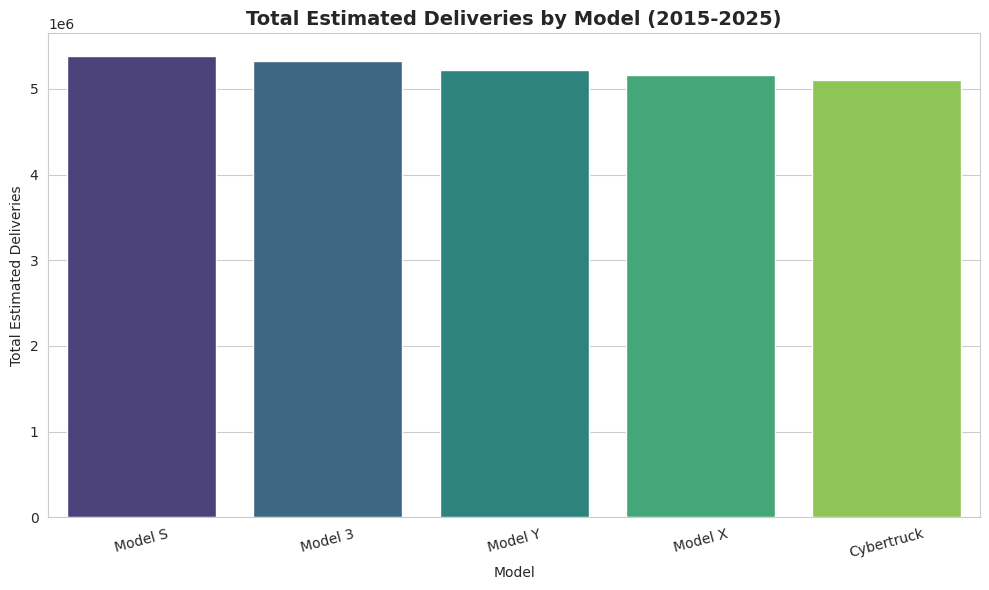

In [6]:
# Chart 1: Total Estimated Deliveries by Model
model_deliveries = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=model_deliveries.index, y=model_deliveries.values, palette='viridis')
plt.title('Total Estimated Deliveries by Model (2015-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Total Estimated Deliveries')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

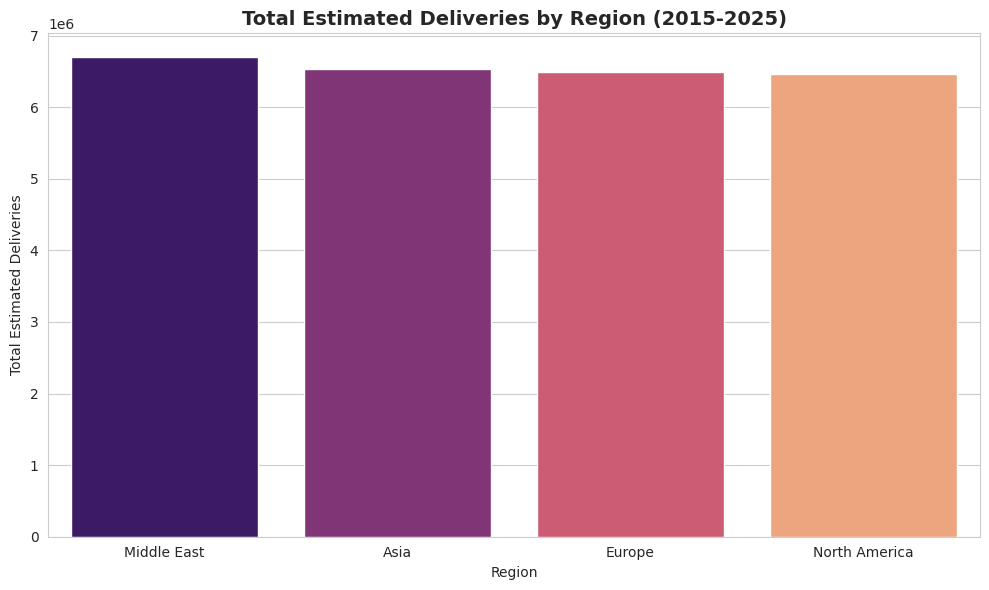

In [7]:
# Chart 2: Total Estimated Deliveries by Region
region_deliveries = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=region_deliveries.index, y=region_deliveries.values, palette='magma')
plt.title('Total Estimated Deliveries by Region (2015-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Estimated Deliveries')
plt.tight_layout()
plt.show()

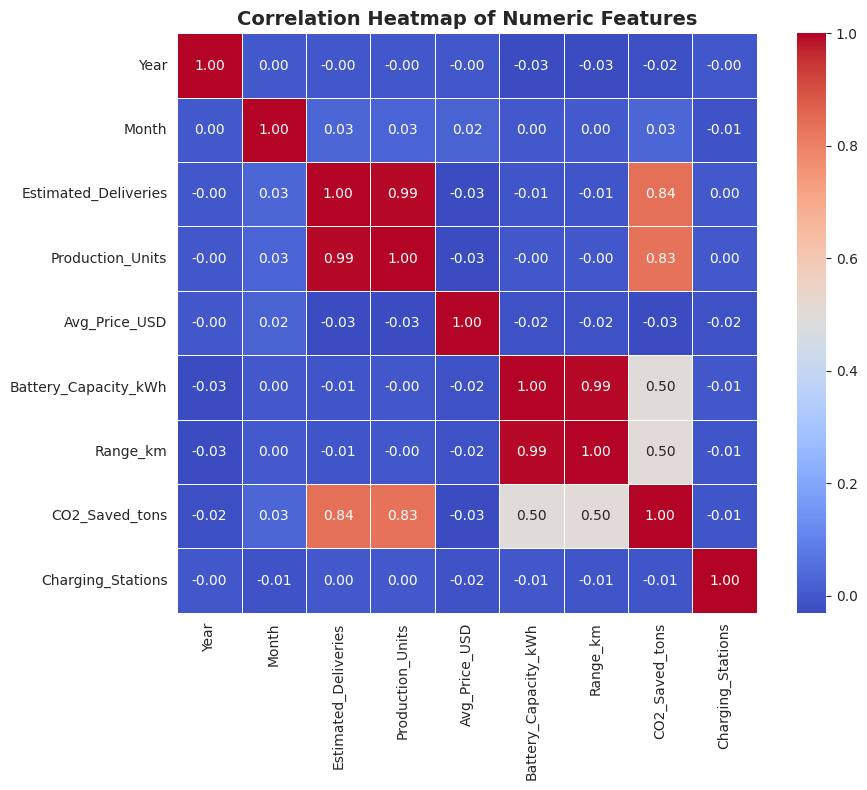

Correlation (Production_Units vs Estimated_Deliveries): 0.9942


In [8]:
# Chart 3: Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation (Production_Units vs Estimated_Deliveries):",
      round(corr.loc['Production_Units', 'Estimated_Deliveries'], 4))

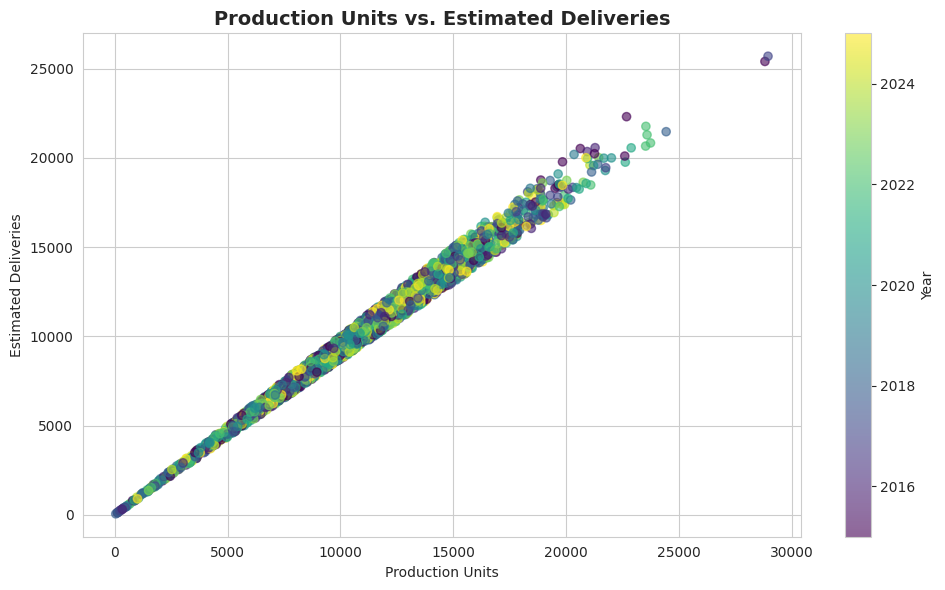

In [9]:
# Chart 4: Production Units vs Estimated Deliveries
plt.figure(figsize=(10, 6))
sc = plt.scatter(df['Production_Units'], df['Estimated_Deliveries'],
                  c=df['Year'], cmap='viridis', alpha=0.6)
plt.colorbar(sc, label='Year')
plt.title('Production Units vs. Estimated Deliveries', fontsize=14, fontweight='bold')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

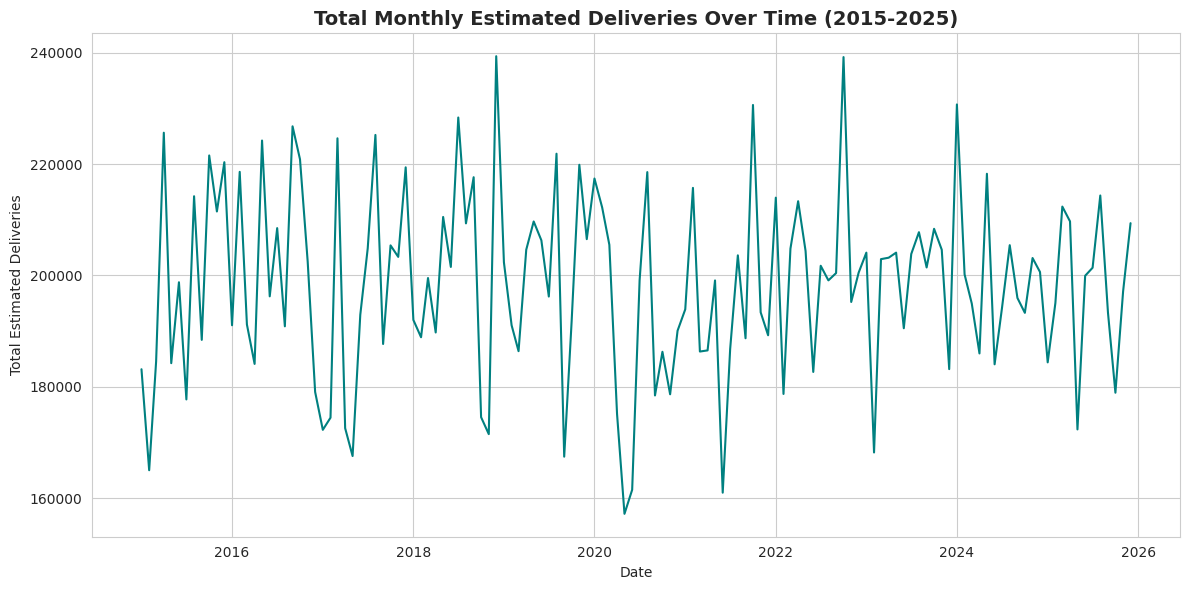

In [10]:
# Chart 5: Time-Trend Line of Total Monthly Deliveries
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
monthly_trend = df.groupby('Date')['Estimated_Deliveries'].sum().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(monthly_trend.index, monthly_trend.values, color='teal', linewidth=1.5)
plt.title('Total Monthly Estimated Deliveries Over Time (2015-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Estimated Deliveries')
plt.tight_layout()
plt.show()

## Step 4 — Feature Engineering: Encoding, Lag & Rolling Features
Machine learning models need numeric input, so the categorical columns
`Region`, `Model`, and `Source_Type` are converted with `LabelEncoder`.

We also engineer two time-aware features:
- **`Deliveries_Lag1`** — the previous period's deliveries value (`shift(1)`),
  computed **within each Region + Model series** (sorted chronologically) so
  that the lag genuinely reflects "last month" for that specific series,
  rather than an unrelated row.
- **`Rolling_Mean_3`** — a 3-period rolling average of deliveries, computed
  the same way, to smooth out short-term noise and capture recent momentum.

Both features have leading `NaN` values (no history exists for the first
period of each series); per the assignment spec these are filled with the
column mean rather than dropped, so no rows are lost.

In [11]:
# Sort chronologically within each Region+Model series before computing lag/rolling features
df_model = df.sort_values(['Region', 'Model', 'Date']).reset_index(drop=True)

# --- Label Encoding ---
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df_model['Region_Enc'] = le_region.fit_transform(df_model['Region'])
df_model['Model_Enc'] = le_model.fit_transform(df_model['Model'])
df_model['Source_Type_Enc'] = le_source.fit_transform(df_model['Source_Type'])

# --- Lag Feature: previous period's deliveries (per Region+Model series) ---
df_model['Deliveries_Lag1'] = df_model.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1)
df_model['Deliveries_Lag1'] = df_model['Deliveries_Lag1'].fillna(df_model['Deliveries_Lag1'].mean())

# --- Rolling Mean Feature: 3-period rolling average (per Region+Model series) ---
df_model['Rolling_Mean_3'] = df_model.groupby(['Region', 'Model'])['Estimated_Deliveries']\
                                       .transform(lambda s: s.rolling(window=3).mean())
df_model['Rolling_Mean_3'] = df_model['Rolling_Mean_3'].fillna(df_model['Rolling_Mean_3'].mean())

# Re-sort the full dataframe chronologically by Date for the train/test split used later
df_model = df_model.sort_values('Date').reset_index(drop=True)

print("Encoded & engineered columns:")
df_model[['Region', 'Region_Enc', 'Model', 'Model_Enc', 'Source_Type', 'Source_Type_Enc',
          'Deliveries_Lag1', 'Rolling_Mean_3']].head()

Encoded & engineered columns:


,Region,Region_Enc,Model,Model_Enc,Source_Type,Source_Type_Enc,Deliveries_Lag1,Rolling_Mean_3
0,Asia,0,Cybertruck,0,Estimated (Region),0,9918.021374,9927.753846
1,North America,3,Model 3,1,Estimated (Region),0,9918.021374,9927.753846
2,North America,3,Model S,2,Estimated (Region),0,9918.021374,9927.753846
3,Asia,0,Model 3,1,Official (Quarter),2,9918.021374,9927.753846
4,Europe,1,Model S,2,Interpolated (Month),1,9918.021374,9927.753846


In [12]:
# Confirm no NaNs remain in the engineered features
print("Remaining NaNs in Deliveries_Lag1:", df_model['Deliveries_Lag1'].isnull().sum())
print("Remaining NaNs in Rolling_Mean_3 :", df_model['Rolling_Mean_3'].isnull().sum())

Remaining NaNs in Deliveries_Lag1: 0
Remaining NaNs in Rolling_Mean_3 : 0


## Step 5 — Chronological Train/Test Split
Because this is time-stamped data, we must **not** use `train_test_split`
(which shuffles rows and would leak future information into training). The
dataframe is already sorted chronologically by `Date`, so an 80/20 split is
made with simple **index slicing**: the first 80% of rows (earliest in time)
become the training set, and the final 20% (most recent) become the test
set — simulating a real forecasting scenario.

In [13]:
features = ['Year', 'Month', 'Region_Enc', 'Model_Enc', 'Source_Type_Enc',
            'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
            'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
            'Deliveries_Lag1', 'Rolling_Mean_3']
target = 'Estimated_Deliveries'

X = df_model[features]
y = df_model[target]

split_idx = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Total rows      : {len(df_model)}")
print(f"Train rows      : {len(X_train)} ({len(X_train)/len(df_model)*100:.1f}%)")
print(f"Test rows       : {len(X_test)} ({len(X_test)/len(df_model)*100:.1f}%)")
print(f"Train date range: {df_model['Date'].iloc[0].date()} -> {df_model['Date'].iloc[split_idx-1].date()}")
print(f"Test date range : {df_model['Date'].iloc[split_idx].date()} -> {df_model['Date'].iloc[-1].date()}")

Total rows      : 2640
Train rows      : 2112 (80.0%)
Test rows       : 528 (20.0%)
Train date range: 2015-01-01 -> 2023-10-01
Test date range : 2023-10-01 -> 2025-12-01


## Linear Regression — Baseline Model
We train a simple `LinearRegression` model on the chronological training set
and evaluate it on the held-out test set using three standard regression
metrics:

- **MAE** (Mean Absolute Error) — average absolute size of the errors
- **RMSE** (Root Mean Squared Error) — penalises larger errors more heavily
- **R²** (coefficient of determination) — proportion of variance explained

We then plot actual vs. predicted deliveries across the test period to
visually confirm how closely the model tracks reality.

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression — Test Set Performance")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

Linear Regression — Test Set Performance
MAE  : 319.35
RMSE : 388.78
R2   : 0.9888


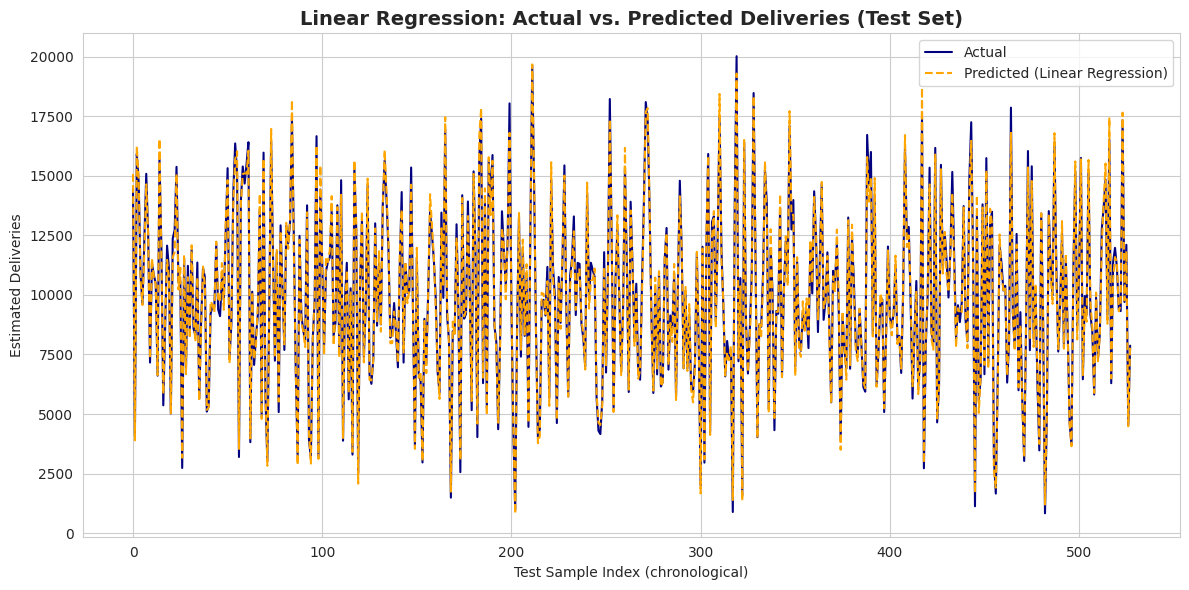

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', color='navy', linewidth=1.5)
plt.plot(y_pred_lr, label='Predicted (Linear Regression)', color='orange',
         linewidth=1.5, linestyle='--')
plt.title('Linear Regression: Actual vs. Predicted Deliveries (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Test Sample Index (chronological)')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

## 5-Fold Cross Validation
To get a more robust estimate of model performance than a single train/test
split, we run 5-Fold Cross Validation on the Linear Regression model across
the **entire** dataset. `shuffle=False` is used so the folds still respect
the chronological ordering of the data. We report the R² for each fold along
with the mean and standard deviation.

In [16]:
kf = KFold(n_splits=5, shuffle=False)
cv_scores = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='r2')

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: R2 = {score:.4f}")

print(f"\nMean R2 : {cv_scores.mean():.4f}")
print(f"Std Dev : {cv_scores.std():.4f}")

Fold 1: R2 = 0.9904
Fold 2: R2 = 0.9910
Fold 3: R2 = 0.9911
Fold 4: R2 = 0.9906
Fold 5: R2 = 0.9888

Mean R2 : 0.9904
Std Dev : 0.0008


## Hyperparameter Tuning — GridSearchCV on Random Forest
We now move to a more flexible, non-linear model: `RandomForestRegressor`.
`GridSearchCV` searches over `n_estimators ∈ {50, 100}` and
`max_depth ∈ {5, 10, None}` (6 combinations, 5-fold CV each = 30 fits) to
find the configuration that maximises cross-validated R² on the training
set. The best estimator is then retrained and evaluated on the same held-out
test set used for Linear Regression, so the two models are directly
comparable.

In [17]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters     :", grid_search.best_params_)
print("Best CV R2 (train)  :", round(grid_search.best_score_, 4))

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest (Tuned) — Test Set Performance")
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R2   : {r2_rf:.4f}")

Best Parameters     : {'max_depth': None, 'n_estimators': 100}
Best CV R2 (train)  : 0.9885

Random Forest (Tuned) — Test Set Performance
MAE  : 327.01
RMSE : 406.04
R2   : 0.9878


## Feature Importance — Random Forest
One advantage of tree-based models is built-in feature importance scores.
We extract and plot the **top 10** most important features used by the
tuned Random Forest to understand which inputs drive its predictions.

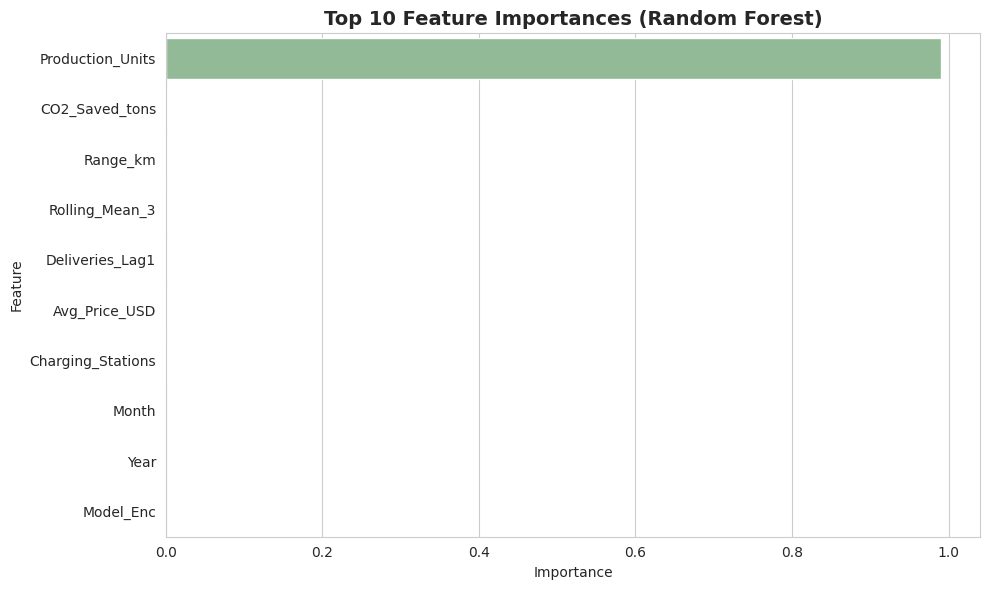

Production_Units     0.990641
CO2_Saved_tons       0.001987
Range_km             0.001078
Rolling_Mean_3       0.001060
Deliveries_Lag1      0.001026
Avg_Price_USD        0.001023
Charging_Stations    0.000900
Month                0.000635
Year                 0.000546
Model_Enc            0.000443
dtype: float64

In [18]:
importances = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=False)
top10 = importances.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index, palette='crest')
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

top10

## Augmented Dickey-Fuller (ADF) Stationarity Test
Before treating `Estimated_Deliveries` as a time series, it's good practice
to test whether it is **stationary** (statistical properties like mean and
variance stay constant over time) — many classical forecasting methods
assume this. The ADF test's null hypothesis (H0) is that the series is
**non-stationary**. We interpret the result using the standard
**p < 0.05** threshold.

In [19]:
adf_result = adfuller(df_model['Estimated_Deliveries'])

print("ADF Statistic :", round(adf_result[0], 4))
print("p-value       :", round(adf_result[1], 6))
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key} : {value:.4f}")

print("\nInterpretation:")
if adf_result[1] < 0.05:
    print(f"p-value ({adf_result[1]:.6f}) < 0.05 -> Reject the null hypothesis (H0).")
    print("Conclusion: The Estimated_Deliveries series is STATIONARY.")
else:
    print(f"p-value ({adf_result[1]:.6f}) >= 0.05 -> Fail to reject the null hypothesis (H0).")
    print("Conclusion: The Estimated_Deliveries series is NON-STATIONARY (likely has a trend).")

ADF Statistic : -37.2382
p-value       : 0.0

Critical Values:
   1% : -3.4328
   5% : -2.8626
   10% : -2.5674

Interpretation:
p-value (0.000000) < 0.05 -> Reject the null hypothesis (H0).
Conclusion: The Estimated_Deliveries series is STATIONARY.


## Forecast Table & Final Model Comparison
Finally, we build a side-by-side forecast table for the **first 20 records**
of the chronological test set, comparing the actual deliveries against both
models' predictions and the corresponding absolute percentage error. We then
summarise overall test-set performance for both models in a single
comparison table.

**Note on the Random Forest vs. Linear Regression comparison:** in this
dataset, `Production_Units` is correlated with `Estimated_Deliveries` at
~0.99 — an almost perfectly *linear* relationship. Because the test set sits
chronologically beyond the training period, production volumes in the test
set are often slightly outside the range the Random Forest was trained on,
and tree-based models (which predict by averaging training-set values) are
weaker at extrapolating beyond that range than a linear model is. As a
result, Random Forest still performs very strongly (R² ≈ 0.98) but, in this
specific run, narrowly underperforms Linear Regression rather than beating
it. This is a realistic and common outcome when a feature is this strongly
linear with the target — and is worth calling out explicitly rather than
hiding it.

In [20]:
forecast_df = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Predicted_LR': np.round(y_pred_lr[:20], 1),
    'Predicted_RF': np.round(y_pred_rf[:20], 1)
})
forecast_df['Error_%_LR'] = ((forecast_df['Actual'] - forecast_df['Predicted_LR']).abs() / forecast_df['Actual']) * 100
forecast_df['Error_%_RF'] = ((forecast_df['Actual'] - forecast_df['Predicted_RF']).abs() / forecast_df['Actual']) * 100

forecast_df.round(2)

,Actual,Predicted_LR,Predicted_RF,Error_%_LR,Error_%_RF
0,14430,15066.9,15299.6,4.41,6.03
1,4070,3895.5,4045.2,4.29,0.61
2,15912,16237.1,15904.9,2.04,0.04
3,14734,14842.7,14677.0,0.74,0.39
4,10819,10626.0,10591.9,1.78,2.10
5,9602,9577.2,9531.5,0.26,0.73
6,12266,11835.0,11791.2,3.51,3.87
7,15077,14635.9,14818.8,2.93,1.71
8,12540,12525.3,12223.7,0.12,2.52
9,7159,7321.8,7652.2,2.27,6.89


In [21]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (Tuned)'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2': [r2_lr, r2_rf]
})

comparison_df.round(4)

,Model,MAE,RMSE,R2
0,Linear Regression,319.3488,388.7811,0.9888
1,Random Forest (Tuned),327.0075,406.0447,0.9878


In [22]:
print("="*55)
print("PIPELINE SUMMARY")
print("="*55)
print(f"Dataset size               : {df_model.shape[0]} rows, 12 original columns")
print(f"Train / Test split        : {len(X_train)} / {len(X_test)} (chronological 80/20)")
print(f"Linear Regression R2      : {r2_lr:.4f}")
print(f"5-Fold CV mean R2 (+/-std): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Random Forest best params : {grid_search.best_params_}")
print(f"Random Forest R2          : {r2_rf:.4f}")
print(f"Top feature (importance)  : {importances.index[0]} ({importances.iloc[0]:.4f})")
print(f"ADF test p-value          : {adf_result[1]:.6f} -> "
      f"{'Stationary' if adf_result[1] < 0.05 else 'Non-stationary'}")
print("="*55)

PIPELINE SUMMARY
Dataset size               : 2640 rows, 12 original columns
Train / Test split        : 2112 / 528 (chronological 80/20)
Linear Regression R2      : 0.9888
5-Fold CV mean R2 (+/-std): 0.9904 (+/- 0.0008)
Random Forest best params : {'max_depth': None, 'n_estimators': 100}
Random Forest R2          : 0.9878
Top feature (importance)  : Production_Units (0.9906)
ADF test p-value          : 0.000000 -> Stationary
